In [2]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py
import sys

sys.path.append('../../../src/benchmark/')
sys.path.append('../../../src/utils/')

from train_functions import train_epochs
from build_model import resnet50_
from utils import viz_dataloader, hdf5_dataset, split_train_valid, list_to_dict, viz_h5_structure

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# FFT - magnitude_spectrum datasets

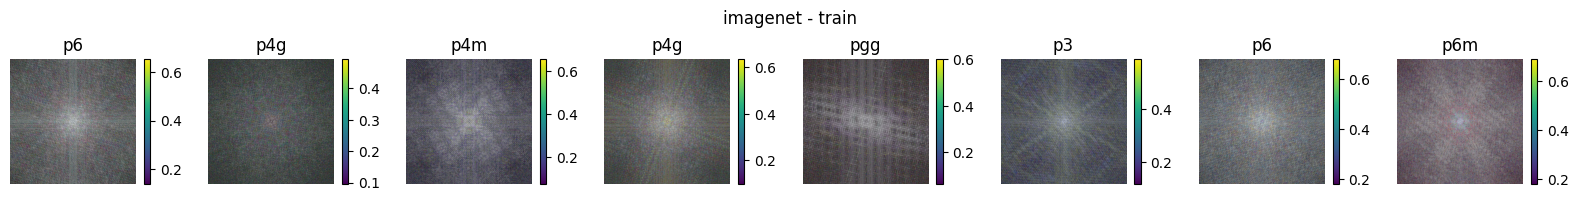

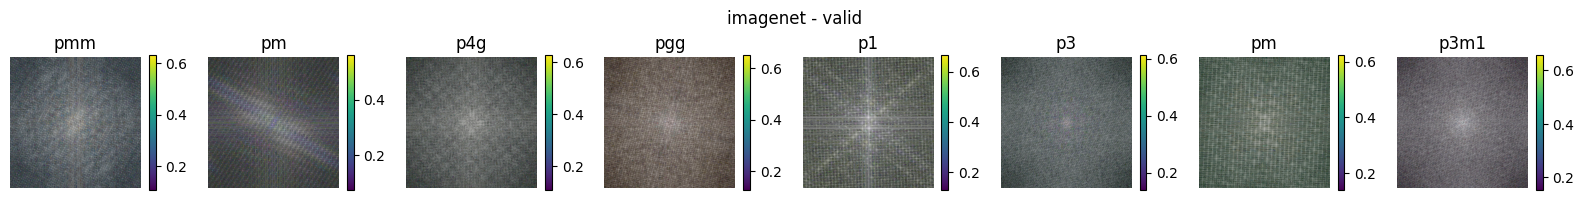

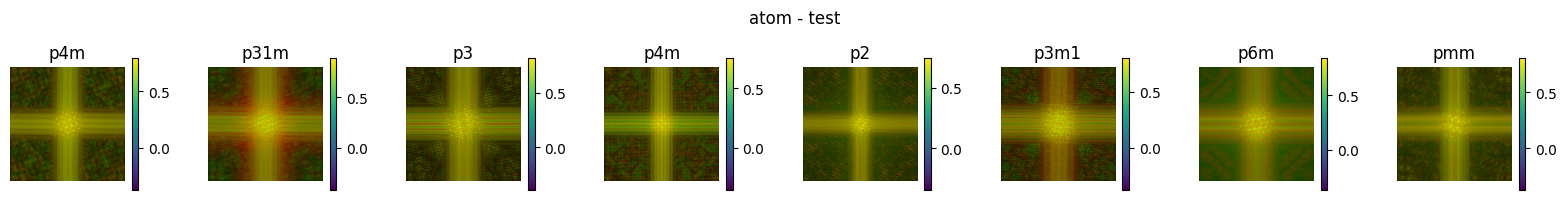

In [4]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
imagenet_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', folder='imagenet', transform=transforms.ToTensor(),
                        data_key='magnitude_spectrum', label_key='labels')
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

train_dl = DataLoader(train_ds, batch_size=600, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train', show_colorbar=True)

valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid', show_colorbar=True)

# atom
test_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', folder='atom', transform=transforms.ToTensor(),
                       data_key='magnitude_spectrum', label_key='labels')
test_dl = DataLoader(test_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(test_dl, label_converter=label_converter, title='atom - test', show_colorbar=True)

In [5]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

torch.Size([2, 17])


In [6]:
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'preprocess-fft_magnitude_spectrum'

In [7]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, save_code=True, config=config, group='preprocess')
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [8]:
device = torch.device('cuda:9')
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


  0%|          | 0/134 [00:00<?, ?it/s]

100%|██████████| 134/134 [01:58<00:00,  1.13it/s]


Training: Loss: 3.0147, Accuracy: 6.7713%, Time: 1.9762mins


100%|██████████| 34/34 [00:11<00:00,  3.01it/s]


...

Training: Loss: 0.0017, Accuracy: 99.9988%, Time: 1.8407mins


100%|██████████| 34/34 [00:11<00:00,  3.08it/s]


Validation : Loss : 0.4882, Accuracy: 90.5950%, Time: 0.18mins


100%|██████████| 167/167 [00:52<00:00,  3.17it/s]


Validation : Loss : 8.1556, Accuracy: 7.7460%, Time: 0.88mins


# FFT - phase_spectrum datasets

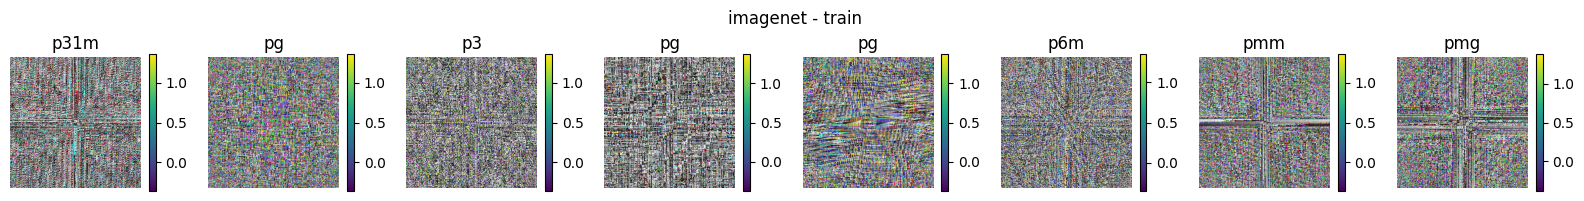

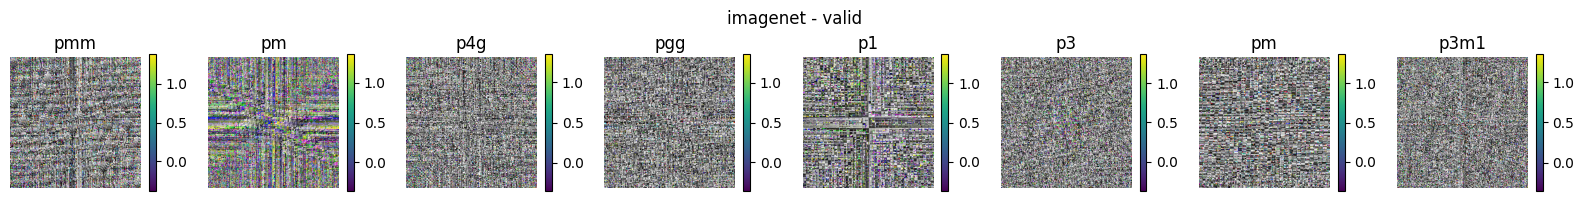

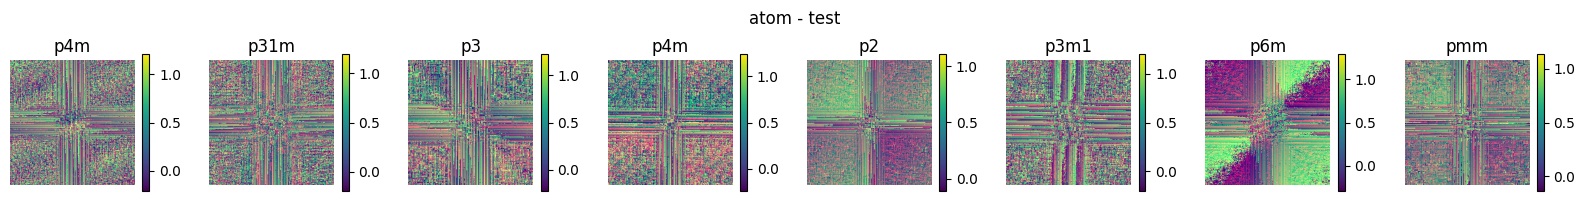

In [9]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
imagenet_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', folder='imagenet', transform=transforms.ToTensor(),
                        data_key='phase_spectrum', label_key='labels')
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

train_dl = DataLoader(train_ds, batch_size=600, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train', show_colorbar=True)

valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid', show_colorbar=True)

# atom
test_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', folder='atom', transform=transforms.ToTensor(),
                       data_key='phase_spectrum', label_key='labels')
test_dl = DataLoader(test_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(test_dl, label_converter=label_converter, title='atom - test', show_colorbar=True)

In [10]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

torch.Size([2, 17])


In [11]:
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'preprocess-fft_phase_spectrum'

In [12]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config, group='preprocess')
config = wandb.config

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
test_acc,▁▁▁▁▁▁▄▁▆▂▃▂▂▃▇▂▂▃█▄▁▆▁▆▃▃▂▇▄▇▄▇▅▇▇▇▇▇▇▆
test_loss,█▆▅▄▁▁▁▂▁▁▁▂▁▂▂▃▄▂▁▄▂▃▄▃▃▂▃▃▃▃▄▄▄▄▄▄▄▄▄▄
train_acc,▁▁▂▃▄▅▅▆▆▆▇▇▇▇▇▇▇███████████████████████
train_loss,██▇▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
valid_acc,▁▁▁▁▄▁▁▁▃▁▁▁▁▁▁▇▁▁▁▇▁▁▁▁▁▁▁▁▁▁█▁▁▁█▁▁▁█▁
valid_loss,█▆▆▅▁▂▂▃▂▂▃▃▃▃▃▁▄▃▂▁▃▄▅▅▄▃▃▄▄▄▁▄▄▅▁▅▅▅▁▅
epoch,49
test_acc,0.07746
test_loss,8.15561
train_acc,0.99999


In [13]:
device = torch.device('cuda:9')
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


100%|██████████| 134/134 [01:49<00:00,  1.22it/s]


Training: Loss: 2.8974, Accuracy: 8.9813%, Time: 1.8305mins


100%|██████████| 34/34 [00:11<00:00,  3.09it/s]


Validation : Loss : 2.6898, Accuracy: 13.6100%, Time: 0.18mins


...

Training: Loss: 0.0133, Accuracy: 99.9500%, Time: 1.8348mins


100%|██████████| 34/34 [00:10<00:00,  3.10it/s]


Validation : Loss : 2.7148, Accuracy: 48.6050%, Time: 0.18mins


100%|██████████| 167/167 [00:51<00:00,  3.23it/s]


Validation : Loss : 8.2249, Accuracy: 8.7690%, Time: 0.86mins


# radon

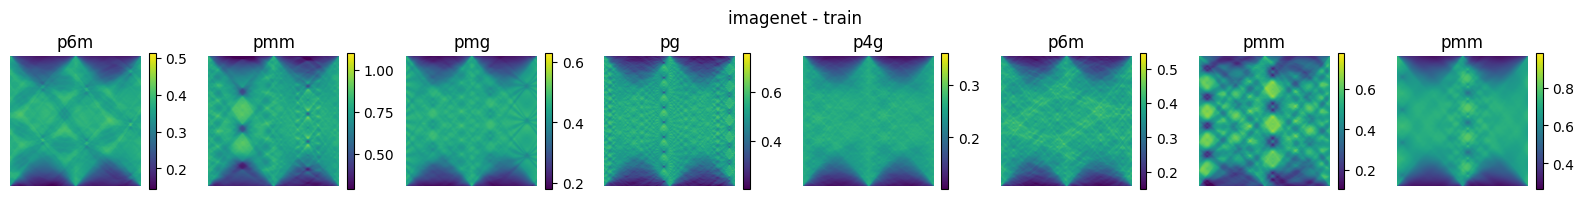

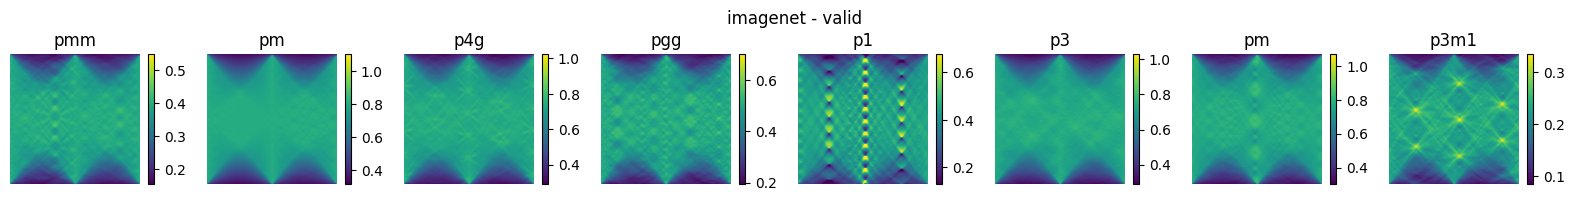

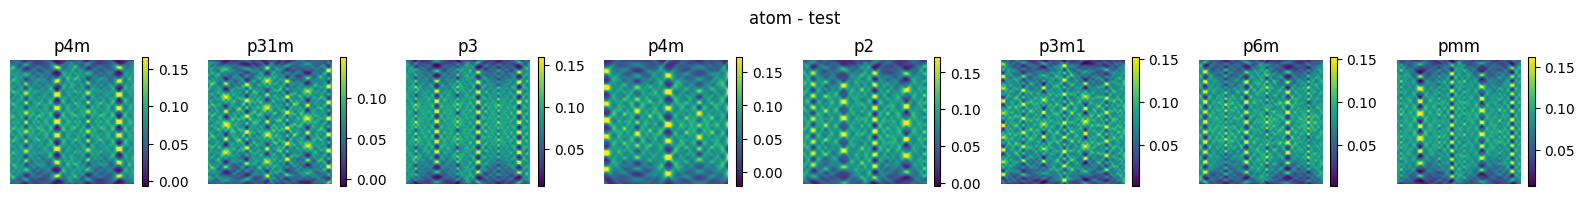

In [14]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
imagenet_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', folder='imagenet', transform=transforms.ToTensor(),
                        data_key='radon', label_key='labels')
train_ds, valid_ds = split_train_valid(imagenet_ds, train_ratio=0.8, seed=42)

train_dl = DataLoader(train_ds, batch_size=600, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train', show_colorbar=True)

valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid', show_colorbar=True)

# atom
test_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_transform.h5', folder='atom', transform=transforms.ToTensor(),
                       data_key='radon', label_key='labels')
test_dl = DataLoader(test_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(test_dl, label_converter=label_converter, title='atom - test', show_colorbar=True)

In [15]:
model = resnet50_(in_channels=1, n_classes=17)
outputs = model(torch.randn(2,1,256,256))
print(outputs.shape)

torch.Size([2, 17])


In [16]:
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'preprocess-radon'

In [17]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config, group='preprocess')
config = wandb.config

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
test_acc,▁▁▁▂▄▂▁▃▆▃▅▃▅▄█▅▇▂▃▄▄▃▂▃▃▅▆▇▄▅▅▅▅▅▅▅▅▅▅▅
test_loss,▂▂▄▂▁▄▆▃▂▃▃▄▄▄▃▄▃▇▅▅▄▇█▄█▆▄▇▇▆▇▇▇███████
train_acc,▁▁▁▂▂▃▃▃▃▄▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇███████████
train_loss,██▇▆▆▅▅▄▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
valid_acc,▁▁▁▂▅▁▁▁▅▂▂▁▂▂▂▄▂▂▁▆▁▁▁█▁▂▂▂▂▂█▂▂▁█▂▁▂█▂
valid_loss,▃▄▅▃▁▅▆▄▁▄▄▅▅▅▄▄▄▇▆▁▅▇█▁█▆▅▇▇▆▂▇▇█▂███▂█
epoch,49
test_acc,0.08769
test_loss,8.22487
train_acc,0.9995


In [18]:
device = torch.device('cuda:9')
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


100%|██████████| 134/134 [01:42<00:00,  1.30it/s]


Training: Loss: 3.0427, Accuracy: 6.0588%, Time: 1.7138mins


100%|██████████| 34/34 [00:08<00:00,  3.82it/s]


Validation : Loss : 2.8643, Accuracy: 5.9350%, Time: 0.15mins


...

Training: Loss: 0.0011, Accuracy: 99.9963%, Time: 1.7208mins


100%|██████████| 34/34 [00:08<00:00,  3.85it/s]


Validation : Loss : 0.1382, Accuracy: 97.1200%, Time: 0.15mins


100%|██████████| 167/167 [00:42<00:00,  3.92it/s]


Validation : Loss : 6.1360, Accuracy: 30.6240%, Time: 0.71mins
